In [ ]:
import sys
import os

# Allow imports from app/src by adding it to sys.path, bcause this notebook is in the root directory
sys.path.append(os.path.abspath("app/src"))

In [3]:
from models.models import ContainerOptimizer

In [4]:
import pandas as pd
import time
import matplotlib.pyplot as plt


# Optional: nicer plots
plt.style.use('ggplot')

In [5]:
df = pd.read_csv("app/src/data/synthetic_data/pallet_dataset.csv")

# Convert to list of dicts
all_pallets = df.to_dict('records')

print(f"Total pallets in dataset: {len(all_pallets)}")

Total pallets in dataset: 100


In [14]:
sizes = [10, 20, 30, 40, 50]  # adjust based the dataset size

In [8]:
results = []

for size in sizes:
    print(f"\nRunning for dataset size: {size}")
    
    pallets = all_pallets[:size]

    # --- GREEDY ---
    optimizer = ContainerOptimizer()
    start = time.time()
    greedy_res = optimizer.greedy_heuristic(pallets.copy())
    greedy_time = time.time() - start

    # --- MILP ---
    optimizer = ContainerOptimizer()
    start = time.time()
    milp_res = optimizer.milp(pallets.copy(), time_limit_seconds=60)  # keep limit small
    milp_time = time.time() - start

    # --- GA ---
    optimizer = ContainerOptimizer()
    start = time.time()
    ga_res = optimizer.genetic_algorithm(pallets.copy(), pop_size=30, generations=30)
    ga_time = time.time() - start

    # Store results
    results.append({
        "size": size,
        
        "greedy_profit": greedy_res["profit"],
        "greedy_time": greedy_time,
        
        "milp_profit": milp_res["profit"],
        "milp_time": milp_time,
        
        "ga_profit": ga_res["profit"],
        "ga_time": ga_time
    })


Running for dataset size: 10

Running for dataset size: 20

Running for dataset size: 30

Running for dataset size: 40

Running for dataset size: 50


In [10]:
results_df = pd.DataFrame(results)
results_df

,size,greedy_profit,greedy_time,milp_profit,milp_time,ga_profit,ga_time
0,10,10874.0,0.718298,10874.0,1.638809,10874.0,0.278777
1,20,28745.0,0.142084,28745.0,2.927673,28745.0,0.367108
2,30,44207.0,0.195570,41482.0,60.298465,44207.0,0.606194
3,40,57085.0,0.178285,22667.0,60.392554,57085.0,0.926450
4,50,63268.0,0.181841,13633.0,60.650114,61850.0,1.714943


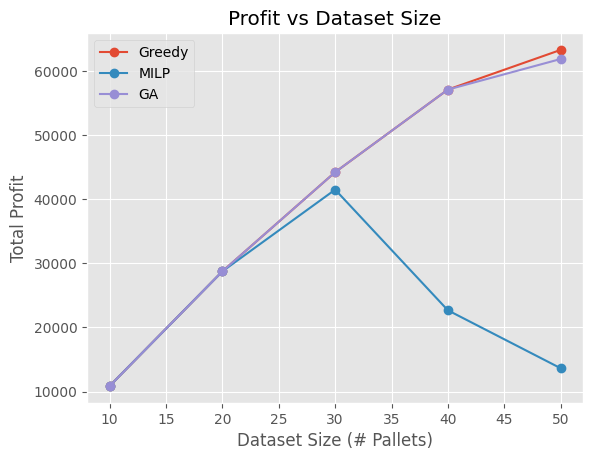

In [11]:
plt.figure()
plt.plot(results_df["size"], results_df["greedy_profit"], marker='o', label="Greedy")
plt.plot(results_df["size"], results_df["milp_profit"], marker='o', label="MILP")
plt.plot(results_df["size"], results_df["ga_profit"], marker='o', label="GA")

plt.xlabel("Dataset Size (# Pallets)")
plt.ylabel("Total Profit")
plt.title("Profit vs Dataset Size")
plt.legend()
plt.show()

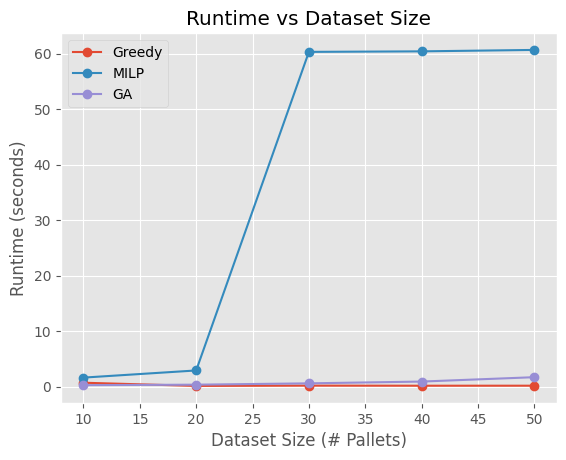

In [12]:
plt.figure()
plt.plot(results_df["size"], results_df["greedy_time"], marker='o', label="Greedy")
plt.plot(results_df["size"], results_df["milp_time"], marker='o', label="MILP")
plt.plot(results_df["size"], results_df["ga_time"], marker='o', label="GA")

plt.xlabel("Dataset Size (# Pallets)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Dataset Size")
plt.legend()
plt.show()

In [13]:
results_df.to_csv("performance_results.csv", index=False)